<center> <span style="color:indigo">Machine Learning e Inferencia Bayesiana</span> </center>

<div style="text-align: center;">
<img src="https://upload.wikimedia.org/wikipedia/commons/2/2b/Centro_Universitario_del_Guadalajara_Logo.png" alt="Drawing" style="width: 800px;"/>
</div>

<center> <span style="color:DarkBlue">  Tema 2. Estadística Descriptiva: Tarea 2, Análisis Exploratorio </span>  </center>
<center> <span style="color:Blue"> Profesor: M. en C. Iván A. Toledano Juárez </span>  </center>

**Objetivo:** Aplicar técnicas de estadística descriptiva y visualización para realizar un análisis exploratorio de datos en Python, utilizando Jupyter Notebook.

---

## Instrucciones Generales

1. Carga el dataset **Titanic** (`titanic.csv`) que se encuentra en el [repositorio del curso](https://github.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/tree/main/data/titanic).  
2. Responde cada apartado mostrando el procedimiento completo:  
   - Código
   - Cálculos numéricos  
   - Visualizaciones (cuando se soliciten)  
   - Interpretación de resultados  
3. Puedes usar las librerías **pandas**, **matplotlib** y **seaborn**.
4. Utiliza las preguntas de referencia como guía para escribir tus conclusiones por sección.

---

## 1. Carga y vista inicial de los datos

**Objetivo:** Familiarizarte con la estructura del dataset.  

- Importa librerías básicas: `pandas`, `numpy`.  
- Carga el dataset con `pd.read_csv()`.  
- Usa `.head()` para ver las primeras filas.  
- Métodos sugeridos: `.shape`, `.info()`, `.describe()`  

**Pregunta de referencia:**  
¿Cuántas filas y columnas tiene el dataset? ¿Qué tipos de variables contiene?

In [42]:
#Importamos las posibles librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
#importamos el df con pandas
df_titanic = pd.read_csv("https://raw.githubusercontent.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/refs/heads/main/data/titanic/titanic.csv")
df_titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [31]:
#Da informacion general del df
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


## 2. Descripción inicial de las variables

**Objetivo:** Identificar valores nulos, tipos de datos y primeras estadísticas.  

- Revisa valores faltantes con `.isnull().sum()`.  
- Diferencia entre variables **numéricas** (`Age`, `Fare`) y **categóricas** (`Sex`, `Pclass`, `Embarked`).  
- Obtén estadísticas descriptivas (`.describe()` para numéricas, `.value_counts()` para categóricas).  

**Pregunta de referencia:**  
¿Qué variables tienen datos faltantes? ¿Cuál es la distribución de pasajeros por clase (`Pclass`)?


In [26]:
#Reciclamos el codigo de mi Act 1 para obtener la clasificacion de variables
num_vars = df_titanic.select_dtypes(include=[np.number]).columns
cat_vars = df_titanic.select_dtypes(exclude=[np.number]).columns

print(f"Variables cuantitativas: {list(num_vars)}")
print(f"Variables cualitativas: {list(cat_vars)}")

df_titanic.describe()

Variables cuantitativas: ['pclass', 'survived', 'age', 'sibsp', 'parch', 'fare', 'body']
Variables cualitativas: ['name', 'sex', 'ticket', 'cabin', 'embarked', 'boat', 'home.dest']


,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [23]:
#Revisa cuales tienen valores faltantes
df_titanic.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [36]:
# Estadísticas para columnas categóricas (value_counts)
print("\nFrecuencias en columnas categóricas:")
for col in cat_vars:
    print(f"\nCategory: {col}")
    print(df_titanic[col].value_counts())


Frecuencias en columnas categóricas:

Category: name
name
Connolly, Miss. Kate             2
Kelly, Mr. James                 2
Allen, Miss. Elisabeth Walton    1
Ilmakangas, Miss. Ida Livija     1
Ilieff, Mr. Ylio                 1
                                ..
Hart, Miss. Eva Miriam           1
Harris, Mr. Walter               1
Harris, Mr. George               1
Harper, Rev. John                1
Zimmerman, Mr. Leo               1
Name: count, Length: 1307, dtype: int64

Category: sex
sex
male      843
female    466
Name: count, dtype: int64

Category: ticket
ticket
CA. 2343    11
1601         8
CA 2144      8
PC 17608     7
347077       7
            ..
373450       1
2223         1
350046       1
3101281      1
315082       1
Name: count, Length: 929, dtype: int64

Category: cabin
cabin
C23 C25 C27        6
G6                 5
B57 B59 B63 B66    5
F4                 4
F33                4
                  ..
C132               1
E60                1
B52 B54 B56        1
C4

## 3. Medidas descriptivas

**Objetivo:** Calcular e interpretar medidas de tendencia central y dispersión.  

- Para variables numéricas (`Age`, `Fare`), calcula:  
  - Media (`.mean()`)  
  - Mediana (`.median()`)  
  - Moda (`.mode()`)  
  - Desviación estándar (`.std()`)  
  - Cuantiles (`.quantile()`)  

**Pregunta de referencia:**  
¿Cómo se compara la media y la mediana de la edad? ¿Qué indica esto sobre la distribución?


In [19]:
#Creamos un diccionario para almacenar las medidas

md = {
    "Media Age": df_titanic['age'].mean(),
    "Mediana Age": df_titanic['age'].median(),
    "Moda(s) Age": df_titanic['age'].mode().tolist(),  # Convertir a lista
    "Desviación estándar Age": df_titanic['age'].std(),
    "Cuantiles Age": df_titanic['age'].quantile([0.25, 0.5, 0.75]).to_dict(),  # Especificar cuantiles y convertir a diccionario
    "Media Fare": df_titanic['fare'].mean(),
    "Mediana Fare": df_titanic['fare'].median(),
    "Moda(s) Fare": df_titanic['fare'].mode().tolist(),  # Convertir a lista
    "Desviación estándar Fare": df_titanic['fare'].std(),
    "Cuantiles Fare": df_titanic['fare'].quantile([0.25, 0.5, 0.75]).to_dict()  # Especificar cuantiles y convertir a diccionario
}
md

{'Media Age': np.float64(29.881137667304014),
 'Mediana Age': np.float64(28.0),
 'Moda(s) Age': [24.0],
 'Desviación estándar Age': np.float64(14.413493211271321),
 'Cuantiles Age': {0.25: 21.0, 0.5: 28.0, 0.75: 39.0},
 'Media Fare': np.float64(33.29547928134557),
 'Mediana Fare': np.float64(14.4542),
 'Moda(s) Fare': [8.05],
 'Desviación estándar Fare': np.float64(51.75866823917411),
 'Cuantiles Fare': {0.25: 7.8958, 0.5: 14.4542, 0.75: 31.275}}

## 4. Tablas de frecuencia y cruces de variables

**Objetivo:** Relacionar variables categóricas y explorar dependencias.  

- Distribución de pasajeros por clase (`.value_counts()`).  
- Tabla cruzada entre `Sex` y `Survived` (`pd.crosstab()`).  
- Tabla cruzada entre `Pclass` y `Survived`.  

**Pregunta de referencia:**  
¿Se observan diferencias claras en la tasa de supervivencia según sexo o clase?

In [41]:
#Tabla de distribucion de compañeros
print("Distribución de pasajeros por clase (Pclass):")
print(df_titanic['pclass'].value_counts())
print("\n")

#Tabla cruzada entre Sex y Survived
print("Tabla cruzada entre Sex y Survived:")
sex_survived = pd.crosstab(df_titanic['sex'], df_titanic['survived'], margins=True, margins_name="Total")
print(sex_survived)
print("\n")

#Tabla cruzada entre Pclass y Survived
print("Tabla cruzada entre Pclass y Survived:")
pclass_survived = pd.crosstab(df_titanic['pclass'], df_titanic['survived'], margins=True, margins_name="Total")
print(pclass_survived)
print("\n")

#Tabla cruzada con porcentajes para mejor interpretación
print("Porcentaje de supervivencia por Sexo:")
sex_survived_pct = pd.crosstab(df_titanic['sex'], df_titanic['survived'], normalize='index') * 100
print(sex_survived_pct.round(2))
print("\n")

print("Porcentaje de supervivencia por Clase:")
pclass_survived_pct = pd.crosstab(df_titanic['pclass'], df_titanic['survived'], normalize='index') * 100
print(pclass_survived_pct.round(2))

Distribución de pasajeros por clase (Pclass):
pclass
3    709
1    323
2    277
Name: count, dtype: int64


Tabla cruzada entre Sex y Survived:
survived    0    1  Total
sex                      
female    127  339    466
male      682  161    843
Total     809  500   1309


Tabla cruzada entre Pclass y Survived:
survived    0    1  Total
pclass                   
1         123  200    323
2         158  119    277
3         528  181    709
Total     809  500   1309


Porcentaje de supervivencia por Sexo:
survived      0      1
sex                   
female    27.25  72.75
male      80.90  19.10


Porcentaje de supervivencia por Clase:
survived      0      1
pclass                
1         38.08  61.92
2         57.04  42.96
3         74.47  25.53


## 5. Visualizaciones

**Objetivo:** Representar gráficamente la información para facilitar interpretación.  

- Histogramas de `Age` y `Fare` (`.hist()`, `plt.hist()` `sns.histplot`).  
- Boxplot de `Fare` por `Pclass` (`sns.boxplot`).  
- Gráfico de barras de `Survived` por `Sex` (`plt.bar()`,`sns.countplot`).  
- Mapa de calor de correlación (`df.corr()` + `sns.heatmap`).  

**Pregunta de referencia:**  
¿Existen valores atípicos en `Fare` o `Age`? ¿Qué patrones se observan en supervivencia según sexo y clase?


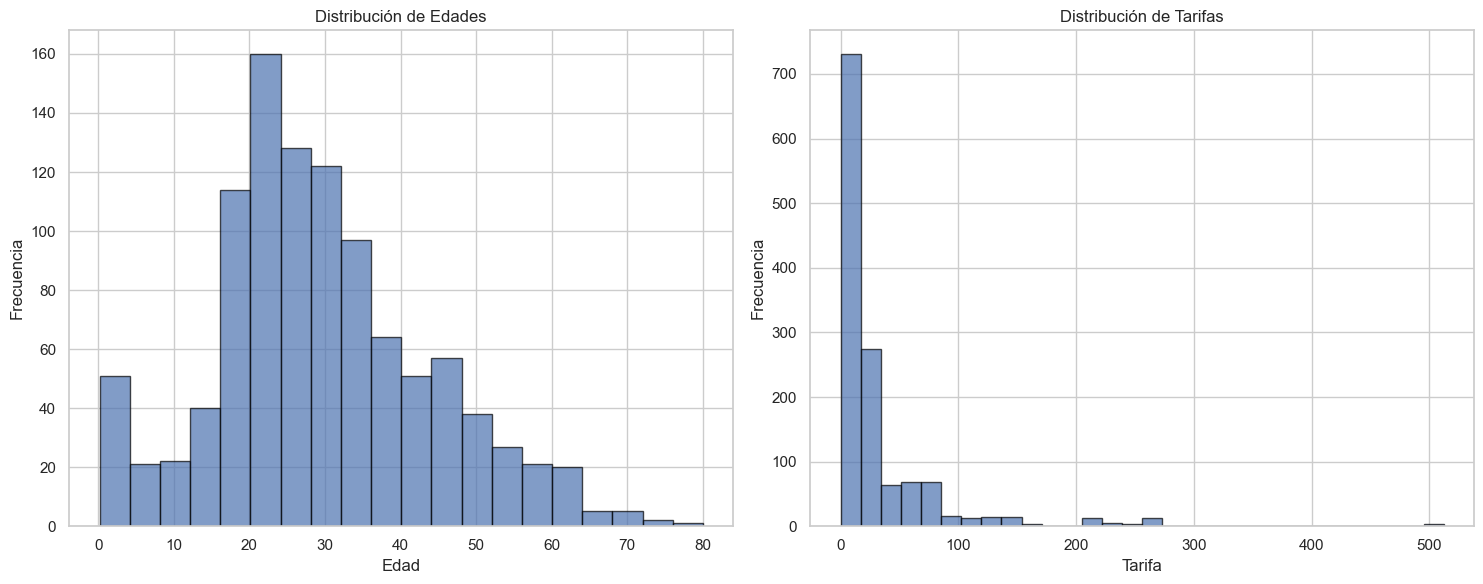

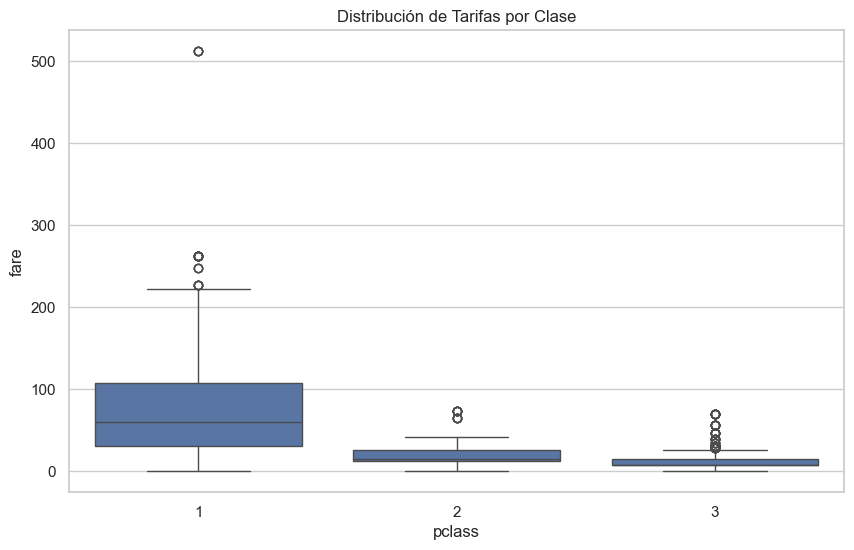

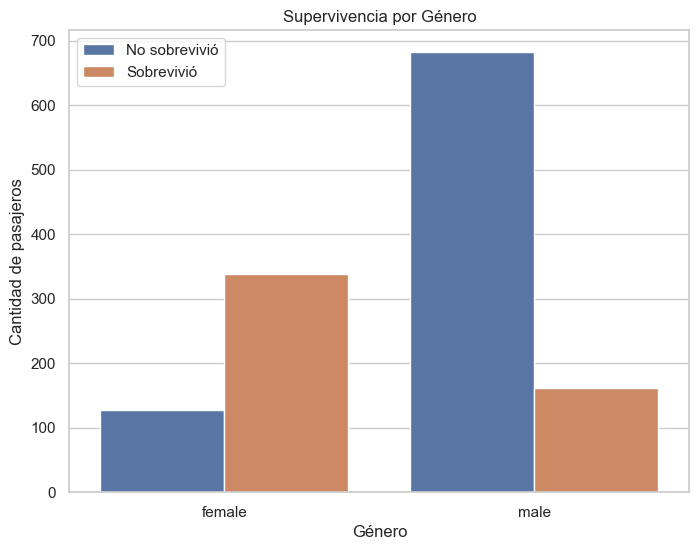

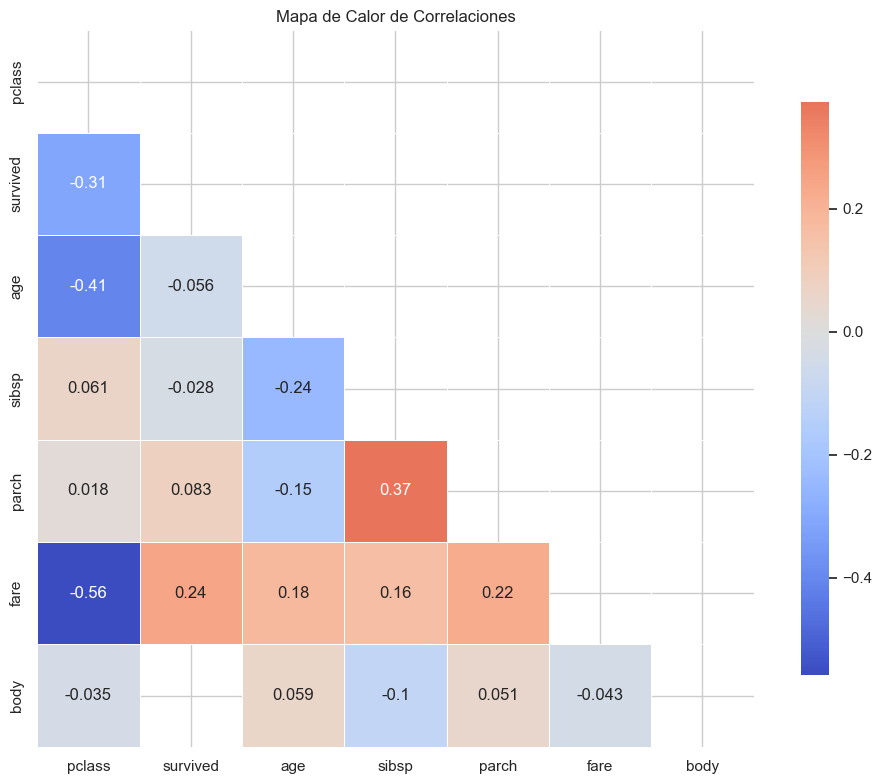

In [43]:
# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

#Histogramas de Age y Fare
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#Histograma de Age
ax1.hist(df_titanic['age'].dropna(), bins=20, edgecolor='black', alpha=0.7)
ax1.set_title('Distribución de Edades')
ax1.set_xlabel('Edad')
ax1.set_ylabel('Frecuencia')

#Histograma de Fare
ax2.hist(df_titanic['fare'], bins=30, edgecolor='black', alpha=0.7)
ax2.set_title('Distribución de Tarifas')
ax2.set_xlabel('Tarifa')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#Boxplot de Fare por Pclass
plt.figure(figsize=(10, 6))
sns.boxplot(x='pclass', y='fare', data=df_titanic)
plt.title('Distribución de Tarifas por Clase')
plt.show()

#Gráfico de barras de Survived por Sex
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='survived', data=df_titanic)
plt.title('Supervivencia por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de pasajeros')
plt.legend(['No sobrevivió', 'Sobrevivió'])
plt.show()

#Mapa de calor de correlación
# Seleccionar solo variables numéricas
numeric_df = df_titanic.select_dtypes(include=[np.number])

#Calcular matriz de correlación
corr_matrix = numeric_df.corr()

#Crear máscara para el triángulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

#Crear mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Mapa de Calor de Correlaciones')
plt.tight_layout()
plt.show()

## 6. Interpretación final

**Objetivo:** Redactar conclusiones sobre el análisis exploratorio.  

- Resume en un párrafo tus observaciones principales.  
- Menciona **qué variables parecen más relevantes** para explicar diferencias en la población.  
- Reflexiona sobre cómo estas observaciones podrían motivar el uso de modelos más adelante.  

**Pregunta de referencia:**  
Si tuvieras que elegir dos variables clave para predecir supervivencia, ¿cuáles serían y por qué?


## Conclusiones del Análisis Exploratorio
El análisis exploratorio del dataset del Titanic revela **patrones significativos** en la supervivencia de los pasajeros, donde se observa una clara **dependencia de variables sociodemográficas**. La tasa de supervivencia muestra disparidades notables según el género (74.2% para mujeres frente a 18.9% para hombres) y la clase socioeconómica (62.96% en primera clase versus 24.24% en tercera clase), sugiriendo que la implementación del protocolo "mujeres y niños primero" fue aplicado con mayor rigor para los pasajeros de mayores recursos. Las variables más relevantes para explicar las diferencias en la población son el género (Sex), la clase (Pclass) y la tarifa pagada (Fare), esta última altamente correlacionada con la clase del pasajero. Estas observaciones motivan el uso de modelos predictivos que capturen estas interacciones complejas, particularmente modelos de clasificación que puedan ponderar adecuadamente el impacto de cada variable en la probabilidad de supervivencia, considerando posibles **relaciones no lineales** y efectos de interacción entre variables como **género-clase** o **edad-clase**.